In [1]:
import src.NLP as nlp
from importlib import reload

reload(nlp)

<module 'src.NLP' from 'c:\\Users\\charl\\OneDrive\\Bureau\\A4\\DIA\\NLP_Supervised_Learning\\notebooks\\src\\NLP.py'>

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path.cwd() / ".." / "data" / "outputs" / "reviews_concat_prepared.csv"


In [3]:
df = pd.read_csv(DATA_DIR)

df.head()

,row_uid,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file,source_id
0,1,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN,avis_1_traduit.xlsx,1
1,2,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN,avis_1_traduit.xlsx,1
2,3,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN,avis_1_traduit.xlsx,1
3,4,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN,avis_1_traduit.xlsx,1
4,5,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN,avis_1_traduit.xlsx,1


In [4]:
# Adding sentiment column into the dataframe
df["sentiment"] = df.dropna(subset=['note'])["note"].apply(nlp.categorize_sentiment)

df = df.dropna(subset=['sentiment', 'avis_en'])

In [5]:
X = df["avis_en"]
y = df["note"]
print(X.isna().sum(), y.isna().sum())

0 0


              precision    recall  f1-score   support

    Negative       0.86      0.82      0.84      2198
     Neutral       0.26      0.40      0.31       676
    Positive       0.86      0.74      0.80      1947

    accuracy                           0.73      4821
   macro avg       0.66      0.65      0.65      4821
weighted avg       0.78      0.73      0.75      4821



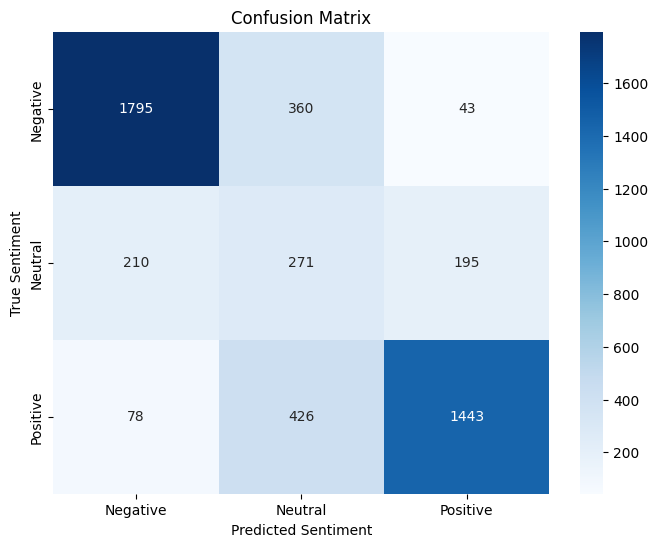

In [6]:
sim_model, X_test, y_test = nlp.train_sim_model(df)
nlp.evaluate_sim_model(sim_model, X_test, y_test)

In [7]:
sim_model.predict(["I hate this insurance company"])

array(['Neutral'], dtype=object)